## Google Colab / GPU setup

In [1]:
# Detect Colab if present
try:
    from google.colab import drive
    COLAB = True
    print('Note: using Google Colab')
except:
    print('Note: not using Google Colab')
    COLAB = False

# Use GPU or MPS (Apple) if available
import torch
device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Note: not using Google Colab
Using device: mps


## H&E Images Dataset

In [2]:
import numpy as np
import os
from collections import defaultdict
from patchify import patchify
from PIL import Image
from torch.utils.data import Dataset


class PatchDataset(Dataset):
    def __init__(self, base_dir, masks_dir, patch_size, step, use_all_patches=False, output_patch_details=False):
        self.base_dir = base_dir
        self.masks_dir = masks_dir
        self.patch_size = patch_size
        self.step = step
        self.use_all_patches = use_all_patches
        self.output_patch_details = output_patch_details
        self.data = []
        self.cores = defaultdict(list)
        self._prepare_dataset()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def create_patches(self, img_array, mask_array):
        img_patches = patchify(img_array, (self.patch_size, self.patch_size, 3), step=self.step)
        mask_patches = patchify(mask_array, (self.patch_size, self.patch_size, 3), step=self.step)
        
        return img_patches, mask_patches
    
    def _is_background_patch(self, patch, threshold=0.8):
        return np.mean(patch > 240) > threshold

    def _has_colour_annotation(self, mask_patch):
        red = np.array([255, 0, 0]) # Red: malignant epithelium
        purple = np.array([165, 55, 156]) # Purple: malignant stroma
        green = np.array([103, 193, 66]) # Orange: non-malignant epithelium
        orange = np.array([243, 143, 53]) # Green: non-malignant stroma
        
        # Check if any coloured annotation pixel exists in the mask
        flat_mask = mask_patch.reshape(-1, mask_patch.shape[-1])
        return np.any(np.all(flat_mask == red, axis=-1)) or \
               np.any(np.all(flat_mask == purple, axis=-1)) or \
               np.any(np.all(flat_mask == green, axis=-1)) or \
               np.any(np.all(flat_mask == orange, axis=-1))
    
    def _pad_image(self, image, target_size=(1576, 1576), fill_color=(255, 255, 255)):
        w, h = image.size
        if w >= target_size[0] and h >= target_size[1]:
            return np.array(image)
        
        padded_image = Image.new('RGB', target_size, fill_color)
        x = (target_size[0] - w) // 2
        y = (target_size[1] - h) // 2
        padded_image.paste(image, (x, y))
        
        return np.array(padded_image)

    def _prepare_dataset(self):
        label_dirs = {'malignant': 1, 'non_malignant': 0}
        for label_dir, label in label_dirs.items():
            img_dir_path = os.path.join(self.base_dir, label_dir)
            mask_dir_path = os.path.join(self.masks_dir, label_dir)
            img_files = {os.path.splitext(f)[0]: os.path.join(img_dir_path, f) for f in os.listdir(img_dir_path) if f.endswith('.tif')}
            mask_files = {os.path.splitext(f)[0]: os.path.join(mask_dir_path, f) for f in os.listdir(mask_dir_path) if f.endswith('.png')}

            common_cores = set(img_files.keys()) & set(mask_files.keys())

            for core_id in common_cores:
                img_file = img_files[core_id]
                mask_file = mask_files[core_id]
                img = Image.open(img_file)
                mask = Image.open(mask_file)
                pad_img = self._pad_image(img)
                pad_mask = self._pad_image(mask)
                img_patches, mask_patches = self.create_patches(pad_img, pad_mask)

                img_patches = img_patches.reshape(-1, self.patch_size, self.patch_size, 3)
                mask_patches = mask_patches.reshape(-1, self.patch_size, self.patch_size, 3)
                core_id = os.path.splitext(os.path.basename(img_file))[0]
                
                for img_patch, mask_patch in zip(img_patches, mask_patches):
                    if not self._is_background_patch(img_patch, threshold=0.9) and (self.use_all_patches or self._has_colour_annotation(mask_patch)):
                        self.data.append((img_patch, label, core_id))
                        self.cores[core_id].append((img_patch, mask_patch, label))

                if self.output_patch_details:
                    print(f'Core {img_file}: {len(self.cores[core_id])} patches')

patches_dataset = PatchDataset('../dataset/he_core_all_images2/', '../dataset/he_core_all_masks/', 224, 224, use_all_patches=False, output_patch_details=True)

print(f'Total valid patches in dataset: {len(patches_dataset)}')

malignant_count = non_malignant_count = 0
for _, label, _ in patches_dataset:
    if label == 1:  
        malignant_count += 1
    elif label == 0: 
        non_malignant_count += 1

print(f'Total malignant patches: {malignant_count}')
print(f'Total non-malignant patches: {non_malignant_count}')

Core ../dataset/he_core_all_images2/malignant/H7.tif: 14 patches
Core ../dataset/he_core_all_images2/malignant/I7.tif: 15 patches
Core ../dataset/he_core_all_images2/malignant/C5.tif: 23 patches
Core ../dataset/he_core_all_images2/malignant/K6.tif: 19 patches
Core ../dataset/he_core_all_images2/malignant/I5.tif: 22 patches
Core ../dataset/he_core_all_images2/malignant/E7.tif: 22 patches
Core ../dataset/he_core_all_images2/malignant/L3.tif: 16 patches
Core ../dataset/he_core_all_images2/malignant/K9.tif: 24 patches
Core ../dataset/he_core_all_images2/malignant/D5.tif: 22 patches
Core ../dataset/he_core_all_images2/malignant/B9.tif: 23 patches
Core ../dataset/he_core_all_images2/malignant/I6.tif: 16 patches
Core ../dataset/he_core_all_images2/malignant/K10.tif: 21 patches
Core ../dataset/he_core_all_images2/malignant/A14.tif: 13 patches
Core ../dataset/he_core_all_images2/malignant/C8.tif: 26 patches
Core ../dataset/he_core_all_images2/malignant/F9.tif: 15 patches
Core ../dataset/he_core

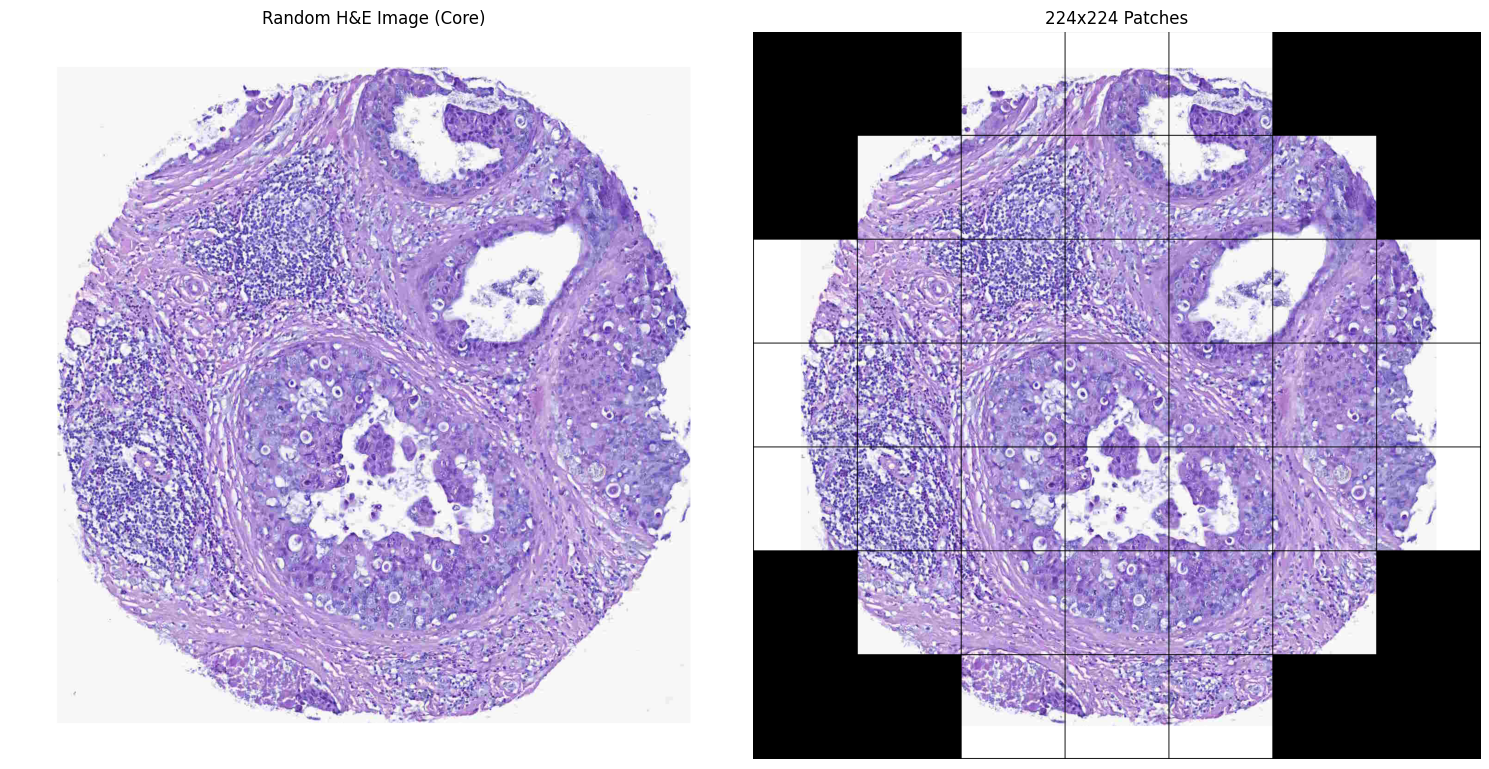

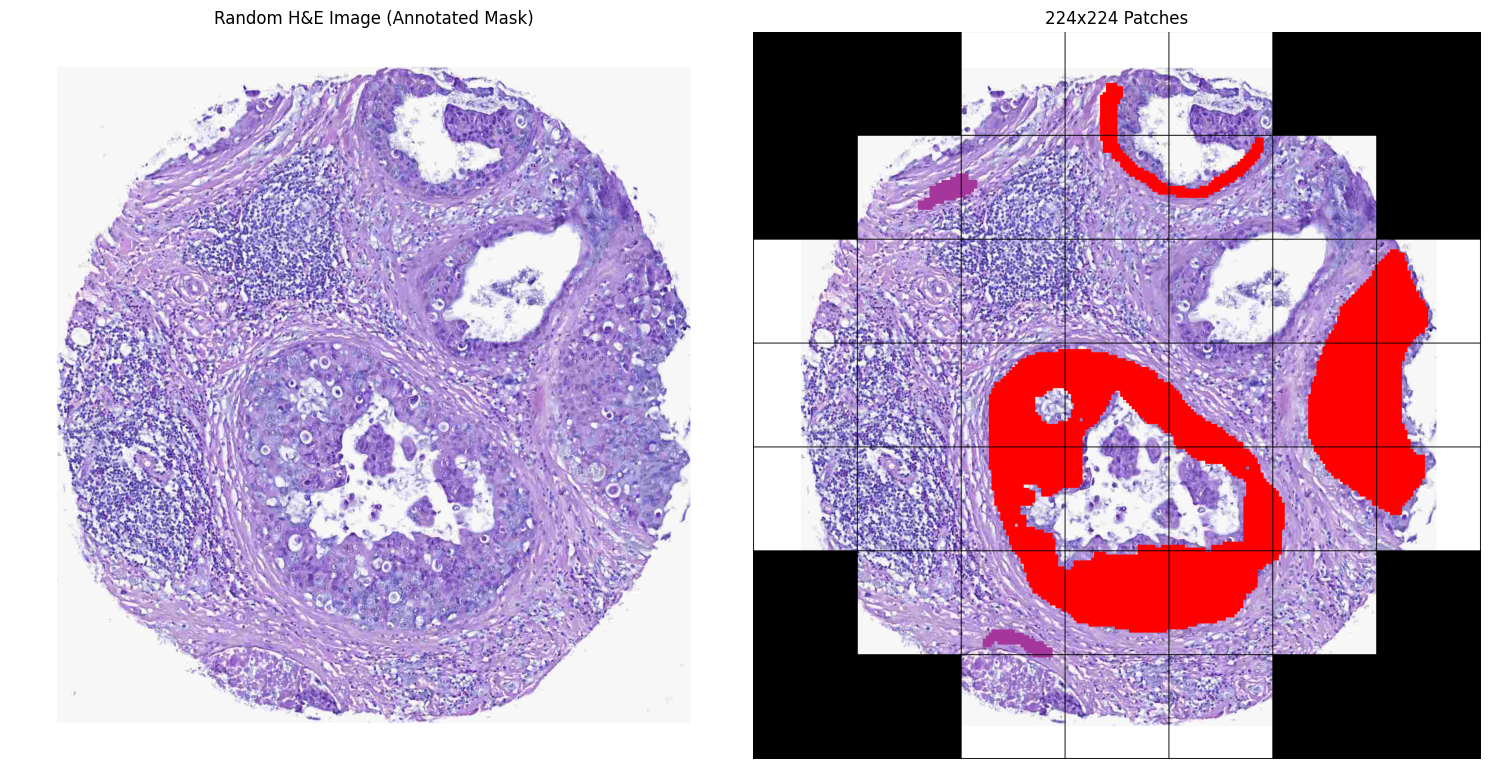

In [3]:
import matplotlib.pyplot as plt
import random

def load_random_image(directory):
    label_dirs = {'malignant': 1, 'non_malignant': 0}
    all_files = []
    for label_dir in label_dirs:
        dir_path = os.path.join(directory, label_dir)
        #files = [os.path.join(dir_path, f) for f in os.listdir(dir_path) if f.endswith('.tif') or f.endswith('.png')]
        # Currently displaying image and mask for D5; above line can be used for random core instead
        files = [os.path.join(dir_path, f) for f in os.listdir(dir_path) if f == 'D5.tif' or f == 'D5.png']
        all_files.extend(files)
    
    random_path = random.choice(all_files)
    img = Image.open(random_path)
    pad_img = pad_image(img)
    return np.array(pad_img), os.path.basename(random_path)

def pad_image(image, target_size=(1576, 1576), fill_color=(255, 255, 255)):
    w, h = image.size
    if w >= target_size[0] and h >= target_size[1]:
        return np.array(image)
    
    padded_image = Image.new('RGB', target_size, fill_color)
    x = (target_size[0] - w) // 2
    y = (target_size[1] - h) // 2
    padded_image.paste(image, (x, y))
    
    return np.array(padded_image)
    
def is_background_patch(patch, threshold=0.9):
        return np.mean(patch > 240) > threshold

def create_patches(img_array, patch_size, step):
    patches = patchify(img_array, (patch_size, patch_size, 3), step=step)
    img_patches = []
    for i in range(patches.shape[0]):
        for j in range(patches.shape[1]):
            if not is_background_patch(patches[i, j, 0], threshold=0.9): 
                img_patches.append((patches[i, j, 0], (i, j)))
    return img_patches

def display_image_and_patches(img_array, patches, dataset_type):
    num_cols = num_rows = 7 
    border_size = 2
    patch_size = patches[0][0].shape[0]  

    grid_height = num_rows * (patch_size + border_size) + border_size
    grid_width = num_cols * (patch_size + border_size) + border_size
    display_grid = np.zeros((grid_height, grid_width, 3), dtype=np.uint8)

    for patch, (i, j) in patches:
        if i < num_rows and j < num_cols:
            start_row = i * (patch_size + border_size) + border_size
            start_col = j * (patch_size + border_size) + border_size
            display_grid[start_row:start_row + patch_size, start_col:start_col + patch_size] = patch

    plt.figure(figsize=(15, 8))  
    ax1 = plt.subplot(1, 2, 1)
    ax1.imshow(img_array)
    ax1.set_title(f'Random H&E Image ({dataset_type})')
    ax1.axis('off')

    ax2 = plt.subplot(1, 2, 2)
    ax2.imshow(display_grid)
    ax2.set_title('224x224 Patches')
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

# Display example H&E image and corresponding mask, with all possible 224x224 patches (excluding 90% background)
image_directory = '../dataset/he_core_all_images/'
mask_directory = '../dataset/he_core_all_masks/' 
full_image, source = load_random_image(image_directory)
patches = create_patches(full_image, 224, 224)  
display_image_and_patches(full_image, patches, 'Core')
full_mask, source = load_random_image(mask_directory)
patches = create_patches(full_mask, 224, 224) 
display_image_and_patches(full_image, patches, 'Annotated Mask')

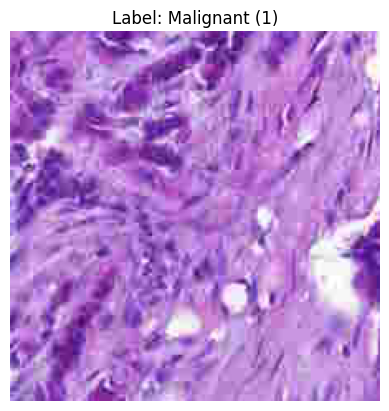

In [10]:
# Display random patch from the dataset
idx = random.randint(0, len(patches_dataset) - 1)
patch, label, _ = patches_dataset[idx]

plt.imshow(patch)
plt.title(f"Label: {'Malignant (1)' if label == 1 else 'Non-malignant (0)'}")
plt.axis('off')
plt.show()

## Augmentations

In [11]:
import cv2

# Source: https://github.com/TissueImageAnalytics/cerberus/blob/master/loader/augs.py

def gaussian_blur(images, random_state, parents, hooks, max_ksize=3):
    img = images[0]  # aleju input batch as default (always=1 in our case)
    ksize = random_state.randint(0, max_ksize, size=(2,))
    ksize = tuple((ksize * 2 + 1).tolist())

    ret = cv2.GaussianBlur(img, ksize, sigmaX=0, sigmaY=0,
                           borderType=cv2.BORDER_REPLICATE)
    ret = np.reshape(ret, img.shape)
    ret = ret.astype(np.uint8)
    return [ret]


def median_blur(images, random_state, parents, hooks, max_ksize=3):
    img = images[0]  # aleju input batch as default (always=1 in our case)
    ksize = random_state.randint(0, max_ksize)
    ksize = ksize * 2 + 1
    ret = cv2.medianBlur(img, ksize)
    ret = ret.astype(np.uint8)
    return [ret]


def add_to_hue(images, random_state, parents, hooks, range=None):
    img = images[0]  # aleju input batch as default (always=1 in our case)
    hue = random_state.uniform(*range)
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    if hsv.dtype.itemsize == 1:
        # OpenCV uses 0-179 for 8-bit images
        hsv[..., 0] = (hsv[..., 0] + hue) % 180
    else:
        # OpenCV uses 0-360 for floating point images
        hsv[..., 0] = (hsv[..., 0] + 2 * hue) % 360
    ret = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
    ret = ret.astype(np.uint8)
    return [ret]


def add_to_saturation(images, random_state, parents, hooks, range=None):
    img = images[0]  # aleju input batch as default (always=1 in our case)
    value = 1 + random_state.uniform(*range)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    ret = img * value + (gray * (1 - value))[:, :, np.newaxis]
    ret = np.clip(ret, 0, 255)
    ret = ret.astype(np.uint8)
    return [ret]


def add_to_contrast(images, random_state, parents, hooks, range=None):
    img = images[0]  # aleju input batch as default (always=1 in our case)
    value = random_state.uniform(*range)
    mean = np.mean(img, axis=(0, 1), keepdims=True)
    ret = img * value + mean * (1 - value)
    ret = np.clip(img, 0, 255)
    ret = ret.astype(np.uint8)
    return [ret]


def add_to_brightness(images, random_state, parents, hooks, range=None):
    img = images[0]  # aleju input batch as default (always=1 in our case)
    value = random_state.uniform(*range)
    ret = np.clip(img + value, 0, 255)
    ret = ret.astype(np.uint8)
    return [ret]

In [12]:
from imgaug import augmenters as iaa
from torch.utils.data import DataLoader
from torchvision import transforms
np.bool = np.bool_

BATCH_SIZE = 32


class ColourAugmentations:
    def __init__(self):
        self.aug = iaa.Sequential([
            iaa.OneOf([
                iaa.Lambda(func_images=lambda *args: gaussian_blur(*args, max_ksize=3)),
                iaa.Lambda(func_images=lambda *args: median_blur(*args, max_ksize=3)),
                iaa.AdditiveGaussianNoise(loc=0, scale=(0.0, 0.05 * 255), per_channel=0.5)
            ]),
            iaa.Sometimes(0.9, iaa.Sequential([
                iaa.Lambda(func_images=lambda *args: add_to_hue(*args, range=(-8, 8))),
                iaa.Lambda(func_images=lambda *args: add_to_saturation(*args, range=(-0.2, 0.2))),
                iaa.Lambda(func_images=lambda *args: add_to_brightness(*args, range=(-26, 26))),
                iaa.Lambda(func_images=lambda *args: add_to_contrast(*args, range=(0.75, 1.25)))
            ], random_order=True))
        ])

    def __call__(self, img):
        img = np.array(img)
        img = img[:, :, ::-1] # RGB TO BGR for OpenCV
        img = self.aug.augment_image(img)
        img = img[:, :, ::-1]  # BGR to RGB for PIL
        img = Image.fromarray(img)
        return img


# Augment training images (patches)
def get_train_transform():
    train_transform = transforms.Compose([
        transforms.ToPILImage(),
        ColourAugmentations(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return train_transform


# Test transform (no augmentation)
def get_test_transform():
    test_transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return test_transform


# Applies augmentations to dataset (necessary to ensure training subset is augmented but not validation subset in cross-validation later)
class WrapperDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        patch, label, core_id = self.base_dataset[idx]
        
        if self.transform:
            patch = self.transform(patch)

        return patch, label, core_id


augmented_dataset = WrapperDataset(base_dataset=patches_dataset, transform=get_train_transform())
dataloader = DataLoader(augmented_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Check first batch as an example
for images, labels, _ in dataloader:
    print(f'Batch shape: {images.shape}, Batch labels: {labels}')
    break

test_set = WrapperDataset(base_dataset=patches_dataset, transform=get_train_transform())
testloader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

for images, labels, core_ids in testloader:
    print(f'Batch shape: {images.shape}, Batch labels: {labels}')
    print(core_ids)
    break

Batch shape: torch.Size([32, 3, 224, 224]), Batch labels: tensor([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1,
        1, 0, 1, 0, 1, 1, 1, 1])
Batch shape: torch.Size([32, 3, 224, 224]), Batch labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])
('H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'H7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'I7', 'C5', 'C5', 'C5')


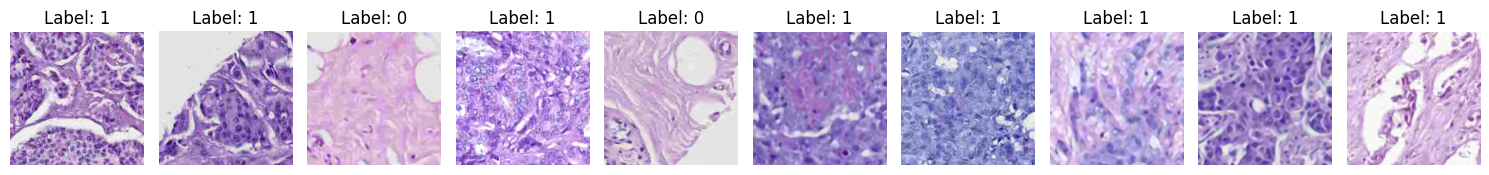

In [14]:
def display(inp, ax, title):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)
    ax.set_title(title)
    ax.axis('off')

def display_random_patches(dataset, num_images=10):
    fig, axs = plt.subplots(1, num_images, figsize=(15, 3))
    axs = axs.flatten()
    total_images = len(dataset)
    random_indices = random.sample(range(total_images), num_images)
    
    for i, idx in enumerate(random_indices):
        image, label, _ = dataset[idx]
        display(image, axs[i], title=f'Label: {label}')

    plt.tight_layout()
    plt.show()

# Display example augmented H&E patches
display_random_patches(augmented_dataset)

## Model Initialisation

In [15]:
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchvision import models
from torchvision.models import ResNet18_Weights


def init_model():
    model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(512, 128),
        nn.Dropout(0.5),
        nn.Linear(128, 2) # binary classification
    )
    
    for name, param in model.named_parameters():
        if 'fc' in name: # unfreeze final layer
            param.requires_grad = True
        else:
            param.requires_grad = False
    
    model.to(device)
    return model

def init_optimiser(model, learning_rate=3e-4):
    optimiser = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    return optimiser

def init_loss_fn():
    weights = torch.tensor([0.8, 0.2]).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=weights)
    return loss_fn


model = init_model()
summary(model, input_size=(8, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [8, 2]                    --
├─Conv2d: 1-1                            [8, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [8, 64, 112, 112]         (128)
├─ReLU: 1-3                              [8, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [8, 64, 56, 56]           --
├─Sequential: 1-5                        [8, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [8, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-2             [8, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [8, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [8, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [8, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [8, 64, 56, 56]   

## Training (Cross-validation)

In [16]:
from torch.utils.data import Subset


# Split patches dataset into training subset (augmented) and validation subset
def setup_data_loaders(train_cores, val_cores, dataset):
    # Train set uses only valid patches from a core; validation set uses all patches from a core
    valid_patches_set = PatchDataset(dataset.base_dir, dataset.masks_dir, dataset.patch_size, dataset.step, use_all_patches=False)
    all_patches_set = PatchDataset(dataset.base_dir, dataset.masks_dir, dataset.patch_size, dataset.step, use_all_patches=True)
    
    train_id = [i for i, (_, _, core_id) in enumerate(valid_patches_set.data) if core_id in train_cores]
    val_id = [i for i, (_, _, core_id) in enumerate(all_patches_set.data) if core_id in val_cores]
    
    train_transform = get_train_transform()
    val_transform = get_test_transform()
    
    train_subset = WrapperDataset(Subset(valid_patches_set, train_id), transform=train_transform)
    val_subset = WrapperDataset(Subset(all_patches_set, val_id), transform=val_transform)
    print(f'Training subset size: {len(train_subset)}')
    print(f'Validation subset size: {len(val_subset)}')
    
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=len(val_subset), shuffle=False)

    return train_loader, val_loader

def get_core_labels(cores):
    core_labels = []
    core_ids = list(cores.keys())
    for core_id in core_ids:
        label = cores[core_id][0][2]
        core_labels.append(label)
    return core_ids, core_labels

In [17]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score


# Model is trained only on valid patches and focuses on patch-level classification
def train(train_loader, model, optimiser, loss_fn):
    model.train()
    epoch_loss = 0
    preds = []
    targets = []

    for batch_idx, (x_batch, y_batch, core_ids) in enumerate(train_loader):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        # Forward pass
        y_batch_pred = model(x_batch)
        loss = loss_fn(y_batch_pred, y_batch)

        # Backward pass and optimisation (adam step)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        epoch_loss += loss.item()

        _, batch_pred = torch.max(y_batch_pred, 1)
        preds.extend(batch_pred.cpu().numpy())
        targets.extend(y_batch.cpu().numpy())        

    avg_loss = epoch_loss / len(train_loader)
    accuracy = accuracy_score(targets, preds)
    return avg_loss, accuracy


# Model is validated on all patches belonging to each core in the validation set; 
# classifies at both spectra-level and core-level (after aggregation)
def validate(val_loader, model, loss_fn):
    model.eval()
    total_loss = 0
    val_preds = []
    val_probs = []
    val_labels = []
    core_outputs = defaultdict(list)  
    core_labels = {} 

    with torch.no_grad():
        for inputs, labels, core_ids in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            val_labels.extend(labels.cpu().numpy())

            _, batch_pred = torch.max(outputs, 1)
            val_preds.extend(batch_pred.cpu().numpy())
            
            probabilities = F.softmax(outputs, dim=1)
            val_probs.extend(probabilities[:, 1].cpu().numpy())

            for i, core_id in enumerate(core_ids):
                core_outputs[core_id].append(probabilities[i, 1].cpu().item())
                core_labels[core_id] = labels[i].item()

    # Aggregate probabilities by core and calculate aggregated predictions
    core_aggregated_probs = {core: np.mean(probs) for core, probs in core_outputs.items()}
    core_aggregated_preds = {core: 1 if prob > 0.5 else 0 for core, prob in core_aggregated_probs.items()}

    ## Print core-level summaries
    #for core in sorted(core_aggregated_probs):
    #    print(f'Core: {core}, Avg Probability: {core_aggregated_probs[core]:.4f}, '
    #          f'Predicted Label: {core_aggregated_preds[core]}, True Label: {core_labels[core]}')

    # Patch-level loss and accuracy
    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(val_labels, val_preds)

    return avg_loss, accuracy, val_probs, val_labels, core_aggregated_probs, core_labels

In [18]:
from sklearn.metrics import accuracy_score, auc, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
from tqdm.auto import tqdm


num_epochs = 30
num_folds = 5
kf = StratifiedKFold(num_folds, shuffle=True)
cores, core_labels = get_core_labels(patches_dataset.cores)
labels = [label for _, label, _ in patches_dataset.data]

all_train_losses = []
all_val_losses = []

fold_val_core_probs = []
fold_val_core_labels = []
fold_val_patch_probs = []
fold_val_patch_labels = []

fold_core_aucs = []
fold_core_accuracies = []
fold_core_precisions = []
fold_core_recalls = []
fold_core_f1_scores = []

fold_patch_accuracies = []
fold_patch_aucs = []
fold_patch_precisions = []
fold_patch_recalls = []
fold_patch_f1_scores = []

for fold, (train_core_id, val_core_id) in enumerate(kf.split(cores, core_labels)):
    train_cores = [cores[i] for i in train_core_id]
    val_cores = [cores[i] for i in val_core_id]
    train_loader, val_loader = setup_data_loaders(train_cores, val_cores, patches_dataset)

    model = init_model()
    optimiser = init_optimiser(model)
    loss_fn = init_loss_fn()

    fold_train_losses = []
    fold_val_losses = []

    with tqdm(total=num_epochs, desc=f'Fold {fold + 1}/{num_folds}', position=0, leave=True) as pbar:
        for epoch in range(num_epochs):
            train_loss, train_acc = train(train_loader, model, optimiser, loss_fn)
            val_loss, val_acc, val_patch_probs, val_patch_labels, val_core_probs, val_core_labels = validate(val_loader, model, loss_fn)

            # Store metrics for the fold (final epoch)
            if epoch == num_epochs - 1:
                # Store patch-level metrics
                val_patch_preds = [1 if p > 0.5 else 0 for p in val_patch_probs]
                patch_auc = roc_auc_score(val_patch_labels, val_patch_probs)
                patch_precision = precision_score(val_patch_labels, val_patch_preds)
                patch_recall = recall_score(val_patch_labels, val_patch_preds)
                patch_f1 = f1_score(val_patch_labels, val_patch_preds)

                fold_patch_accuracies.append(val_acc)
                fold_patch_aucs.append(patch_auc)
                fold_patch_precisions.append(patch_precision)
                fold_patch_recalls.append(patch_recall)
                fold_patch_f1_scores.append(patch_f1)

                # Store core-level metrics
                val_core_preds = [1 if p > 0.5 else 0 for p in val_core_probs.values()]
                val_core_true_labels = list(val_core_labels.values())
                core_accuracy = accuracy_score(val_core_true_labels, val_core_preds)
                core_auc = roc_auc_score(val_core_true_labels, list(val_core_probs.values()))
                core_precision = precision_score(val_core_true_labels, val_core_preds)
                core_recall = recall_score(val_core_true_labels, val_core_preds)
                core_f1 = f1_score(val_core_true_labels, val_core_preds)

                fold_core_accuracies.append(core_accuracy)
                fold_core_aucs.append(core_auc)
                fold_core_precisions.append(core_precision)
                fold_core_recalls.append(core_recall)
                fold_core_f1_scores.append(core_f1)

            fold_train_losses.append(train_loss)
            fold_val_losses.append(val_loss)
            
            # Patch-level
            print(f'Epoch [{epoch + 1}/{num_epochs}]\nTrain Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}' \
                  f'\nTrain Acc: {train_acc * 100:.2f}%, Val Acc: {val_acc * 100:.2f}%\n')
            pbar.update(1)

    all_train_losses.append(fold_train_losses)
    all_val_losses.append(fold_val_losses)
    fold_val_patch_probs.append(val_patch_probs)
    fold_val_patch_labels.append(val_patch_labels)
    fold_val_core_probs.append(val_core_probs)
    fold_val_core_labels.append(val_core_labels)

Training subset size: 710
Validation subset size: 374


Fold 1/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.5882, Val Loss: 0.4539
Train Acc: 63.66%, Val Acc: 80.48%

Epoch [2/30]
Train Loss: 0.3377, Val Loss: 0.3499
Train Acc: 86.62%, Val Acc: 83.16%

Epoch [3/30]
Train Loss: 0.3068, Val Loss: 0.2898
Train Acc: 88.45%, Val Acc: 87.70%

Epoch [4/30]
Train Loss: 0.2596, Val Loss: 0.2831
Train Acc: 89.58%, Val Acc: 91.71%

Epoch [5/30]
Train Loss: 0.2734, Val Loss: 0.3544
Train Acc: 89.86%, Val Acc: 76.20%

Epoch [6/30]
Train Loss: 0.2367, Val Loss: 0.2762
Train Acc: 88.45%, Val Acc: 85.03%

Epoch [7/30]
Train Loss: 0.2371, Val Loss: 0.2360
Train Acc: 89.30%, Val Acc: 89.84%

Epoch [8/30]
Train Loss: 0.2191, Val Loss: 0.2302
Train Acc: 92.39%, Val Acc: 90.37%

Epoch [9/30]
Train Loss: 0.2106, Val Loss: 0.2282
Train Acc: 90.00%, Val Acc: 90.64%

Epoch [10/30]
Train Loss: 0.1922, Val Loss: 0.2291
Train Acc: 92.54%, Val Acc: 89.04%

Epoch [11/30]
Train Loss: 0.2013, Val Loss: 0.2394
Train Acc: 90.00%, Val Acc: 91.18%

Epoch [12/30]
Train Loss: 0.1913, Val Loss: 0.2279
T

Fold 2/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.5842, Val Loss: 0.3927
Train Acc: 61.56%, Val Acc: 82.57%

Epoch [2/30]
Train Loss: 0.3847, Val Loss: 0.2970
Train Acc: 83.09%, Val Acc: 84.99%

Epoch [3/30]
Train Loss: 0.3206, Val Loss: 0.2294
Train Acc: 86.42%, Val Acc: 89.81%

Epoch [4/30]
Train Loss: 0.2663, Val Loss: 0.1849
Train Acc: 89.31%, Val Acc: 92.23%

Epoch [5/30]
Train Loss: 0.2427, Val Loss: 0.1725
Train Acc: 88.58%, Val Acc: 92.49%

Epoch [6/30]
Train Loss: 0.2330, Val Loss: 0.1687
Train Acc: 89.88%, Val Acc: 91.96%

Epoch [7/30]
Train Loss: 0.2046, Val Loss: 0.1904
Train Acc: 92.34%, Val Acc: 88.74%

Epoch [8/30]
Train Loss: 0.2272, Val Loss: 0.1930
Train Acc: 91.33%, Val Acc: 87.13%

Epoch [9/30]
Train Loss: 0.1827, Val Loss: 0.1613
Train Acc: 92.49%, Val Acc: 91.96%

Epoch [10/30]
Train Loss: 0.1986, Val Loss: 0.1427
Train Acc: 91.33%, Val Acc: 93.57%

Epoch [11/30]
Train Loss: 0.1889, Val Loss: 0.1330
Train Acc: 91.91%, Val Acc: 93.30%

Epoch [12/30]
Train Loss: 0.2166, Val Loss: 0.1583
T

...

Epoch [1/30]
Train Loss: 0.6113, Val Loss: 0.4989
Train Acc: 62.81%, Val Acc: 49.33%

Epoch [2/30]
Train Loss: 0.4212, Val Loss: 0.2554
Train Acc: 78.10%, Val Acc: 92.18%

Epoch [3/30]
Train Loss: 0.3329, Val Loss: 0.1718
Train Acc: 86.23%, Val Acc: 96.77%

Epoch [4/30]
Train Loss: 0.3054, Val Loss: 0.1763
Train Acc: 88.15%, Val Acc: 92.99%

Epoch [5/30]
Train Loss: 0.2545, Val Loss: 0.1420
Train Acc: 88.15%, Val Acc: 96.23%

Epoch [6/30]
Train Loss: 0.2543, Val Loss: 0.1247
Train Acc: 88.57%, Val Acc: 96.23%

Epoch [7/30]
Train Loss: 0.2247, Val Loss: 0.1219
Train Acc: 90.36%, Val Acc: 95.15%

Epoch [8/30]
Train Loss: 0.2116, Val Loss: 0.1380
Train Acc: 90.36%, Val Acc: 93.26%

Epoch [9/30]
Train Loss: 0.2205, Val Loss: 0.1399
Train Acc: 89.12%, Val Acc: 91.91%

Epoch [10/30]
Train Loss: 0.1759, Val Loss: 0.0933
Train Acc: 91.60%, Val Acc: 97.84%

Epoch [11/30]
Train Loss: 0.2303, Val Loss: 0.1107
Train Acc: 90.91%, Val Acc: 95.15%

Epoch [12/30]
Train Loss: 0.2101, Val Loss: 0.0805
T

Fold 4/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.5719, Val Loss: 0.5297
Train Acc: 57.38%, Val Acc: 85.19%

Epoch [2/30]
Train Loss: 0.3842, Val Loss: 0.4106
Train Acc: 85.09%, Val Acc: 85.98%

Epoch [3/30]
Train Loss: 0.2667, Val Loss: 0.3899
Train Acc: 87.48%, Val Acc: 87.57%

Epoch [4/30]
Train Loss: 0.2989, Val Loss: 0.4488
Train Acc: 86.92%, Val Acc: 87.57%

Epoch [5/30]
Train Loss: 0.2454, Val Loss: 0.3822
Train Acc: 89.31%, Val Acc: 87.30%

Epoch [6/30]
Train Loss: 0.2432, Val Loss: 0.3488
Train Acc: 88.33%, Val Acc: 86.77%

Epoch [7/30]
Train Loss: 0.2031, Val Loss: 0.3463
Train Acc: 92.12%, Val Acc: 78.57%

Epoch [8/30]
Train Loss: 0.1784, Val Loss: 0.3634
Train Acc: 90.86%, Val Acc: 86.51%

Epoch [9/30]
Train Loss: 0.1472, Val Loss: 0.3904
Train Acc: 92.69%, Val Acc: 86.77%

Epoch [10/30]
Train Loss: 0.1777, Val Loss: 0.3850
Train Acc: 92.97%, Val Acc: 84.92%

Epoch [11/30]
Train Loss: 0.1541, Val Loss: 0.4691
Train Acc: 93.25%, Val Acc: 87.83%

Epoch [12/30]
Train Loss: 0.1701, Val Loss: 0.3531
T

Fold 5/5:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch [1/30]
Train Loss: 0.6355, Val Loss: 0.4306
Train Acc: 58.62%, Val Acc: 93.01%

Epoch [2/30]
Train Loss: 0.4331, Val Loss: 0.2729
Train Acc: 78.02%, Val Acc: 92.47%

Epoch [3/30]
Train Loss: 0.3667, Val Loss: 0.2421
Train Acc: 83.31%, Val Acc: 90.32%

Epoch [4/30]
Train Loss: 0.2960, Val Loss: 0.2050
Train Acc: 88.06%, Val Acc: 95.70%

Epoch [5/30]
Train Loss: 0.2823, Val Loss: 0.1880
Train Acc: 86.57%, Val Acc: 94.62%

Epoch [6/30]
Train Loss: 0.2637, Val Loss: 0.1692
Train Acc: 87.25%, Val Acc: 93.82%

Epoch [7/30]
Train Loss: 0.2833, Val Loss: 0.1569
Train Acc: 86.84%, Val Acc: 95.97%

Epoch [8/30]
Train Loss: 0.2612, Val Loss: 0.1391
Train Acc: 89.28%, Val Acc: 94.09%

Epoch [9/30]
Train Loss: 0.2624, Val Loss: 0.1646
Train Acc: 90.91%, Val Acc: 90.59%

Epoch [10/30]
Train Loss: 0.2357, Val Loss: 0.1554
Train Acc: 89.55%, Val Acc: 91.40%

Epoch [11/30]
Train Loss: 0.3133, Val Loss: 0.1385
Train Acc: 88.47%, Val Acc: 93.01%

Epoch [12/30]
Train Loss: 0.2045, Val Loss: 0.1928
T

## Results

In [22]:
def output_stats(name, array):
    mean = np.mean(array)
    std = np.std(array)
    print(f'{name:<25} Mean: {mean:.4f} ± {std:.4f}')

print('Patch-level metrics (across 5 folds):')
print('-' * 48)
output_stats('Accuracies', fold_patch_accuracies)
output_stats('AUCs', fold_patch_aucs)
output_stats('Precisions', fold_patch_precisions)
output_stats('Recalls', fold_patch_recalls)
output_stats('F1 Scores', fold_patch_f1_scores)

print('\nCore-level metrics (across 5 folds):')
print('-' * 48)
output_stats('Accuracies', fold_core_accuracies)
output_stats('AUCs', fold_core_aucs)
output_stats('Precisions', fold_core_precisions)
output_stats('Recalls', fold_core_recalls)
output_stats('F1 Scores', fold_core_f1_scores)

Patch-level metrics (across 5 folds):
------------------------------------------------
Accuracies                Mean: 0.8697 ± 0.0472
AUCs                      Mean: 0.9746 ± 0.0325
Precisions                Mean: 0.9823 ± 0.0240
Recalls                   Mean: 0.8531 ± 0.0441
F1 Scores                 Mean: 0.9127 ± 0.0326

Core-level metrics (across 5 folds):
------------------------------------------------
Accuracies                Mean: 0.9200 ± 0.0400
AUCs                      Mean: 1.0000 ± 0.0000
Precisions                Mean: 1.0000 ± 0.0000
Recalls                   Mean: 0.9000 ± 0.0500
F1 Scores                 Mean: 0.9467 ± 0.0267


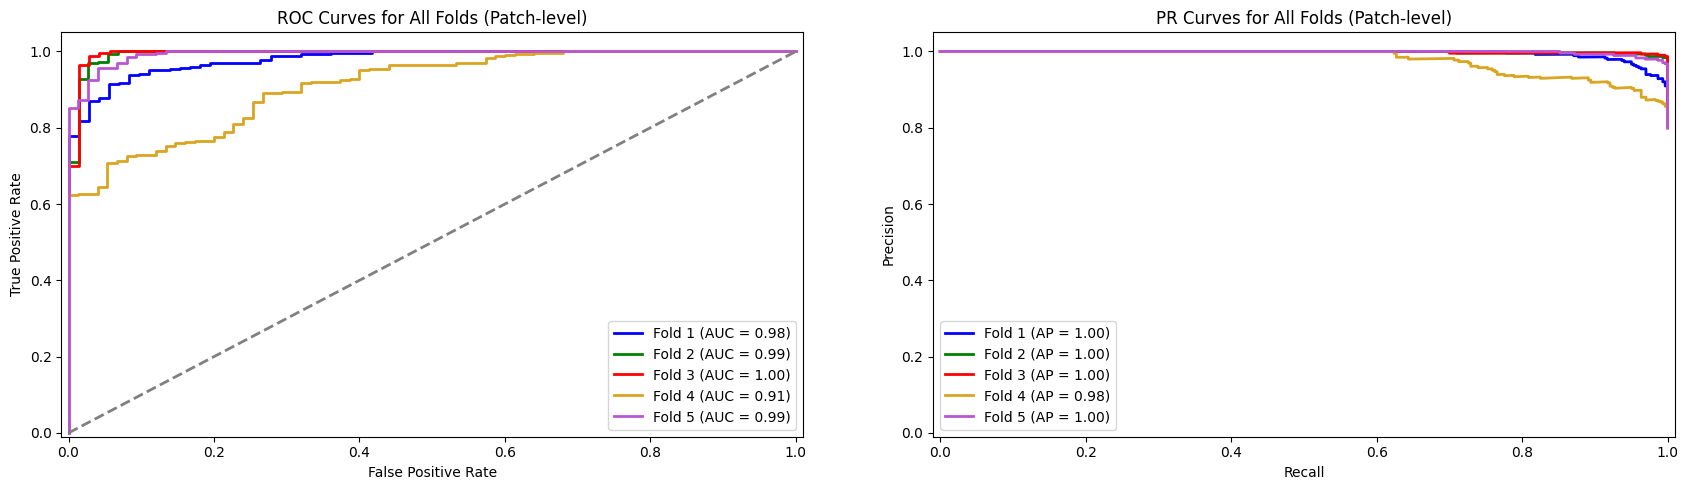

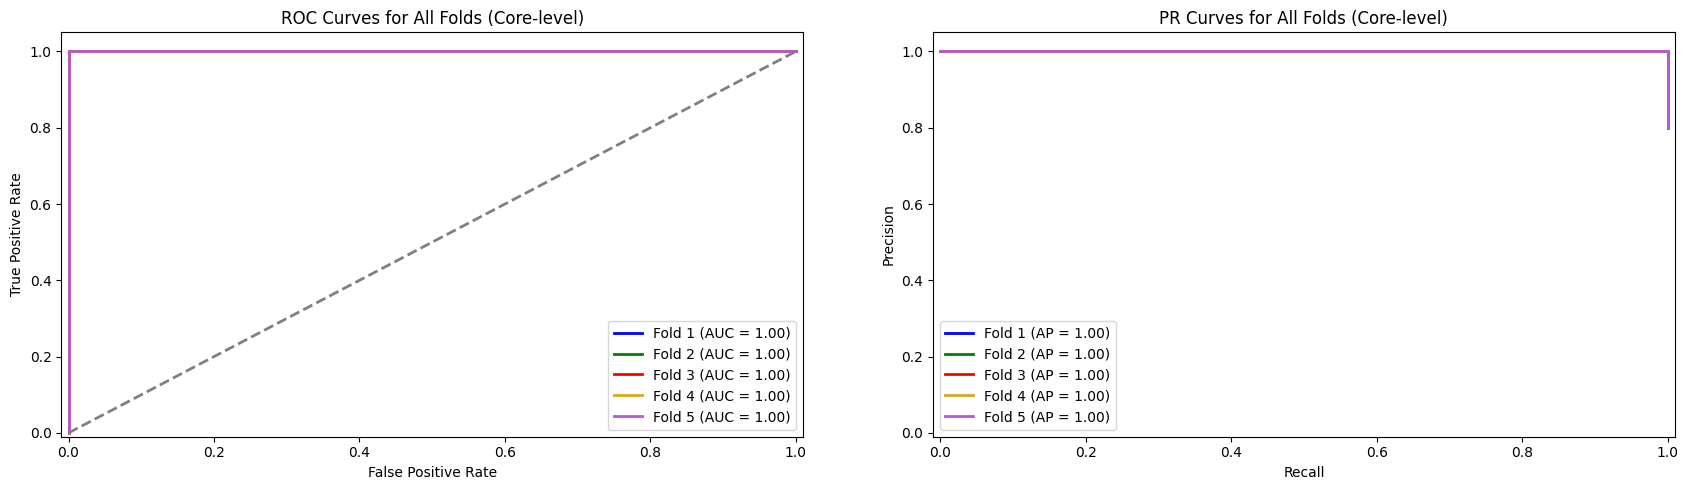

In [23]:
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score


def process_core_data(core_labels, core_probs):
    processed_labels = []
    processed_probs = []
    
    for fold_labels, fold_probs in zip(core_labels, core_probs):
        fold_labels_list = list(fold_labels.values())
        fold_probs_list = list(fold_probs.values())
        processed_labels.append(np.array(fold_labels_list))
        processed_probs.append(np.array(fold_probs_list))
    
    return processed_labels, processed_probs

def plot_roc_pr_curves(fold_val_patch_probs, fold_val_patch_labels, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
    colours = ['blue', 'green', 'red', 'goldenrod', 'mediumorchid']

    # ROC Curves for each fold
    for fold in range(len(fold_val_patch_probs)):
        fpr, tpr, _ = roc_curve(fold_val_patch_labels[fold], fold_val_patch_probs[fold])
        roc_auc = auc(fpr, tpr)
        ax1.plot(fpr, tpr, color=colours[fold], lw=2, 
                 label=f'Fold {fold+1} (AUC = {roc_auc:.2f})')

    ax1.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    ax1.set_xlim([-0.01, 1.01])
    ax1.set_ylim([-0.01, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curves for All Folds ({title})')
    ax1.legend(loc='lower right')

    # PR Curves for each fold
    for fold in range(len(fold_val_patch_probs)):
        precision, recall, _ = precision_recall_curve(fold_val_patch_labels[fold], fold_val_patch_probs[fold])
        avg_prec = average_precision_score(fold_val_patch_labels[fold], fold_val_patch_probs[fold])
        ax2.plot(recall, precision, color=colours[fold], lw=2,
                 label=f'Fold {fold+1} (AP = {avg_prec:.2f})')

    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'PR Curves for All Folds ({title})')
    ax2.set_xlim([-0.01, 1.01])
    ax2.set_ylim([-0.01, 1.05])
    ax2.legend(loc='lower left')
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.175) 
    plt.show()


# Plot ROC and PR curves for each fold, at patch-level and core-level
plot_roc_pr_curves(fold_val_patch_probs, fold_val_patch_labels, title='Patch-level')
core_labels, core_probs = process_core_data(fold_val_core_labels, fold_val_core_probs)
plot_roc_pr_curves(core_probs, core_labels, title='Core-level')

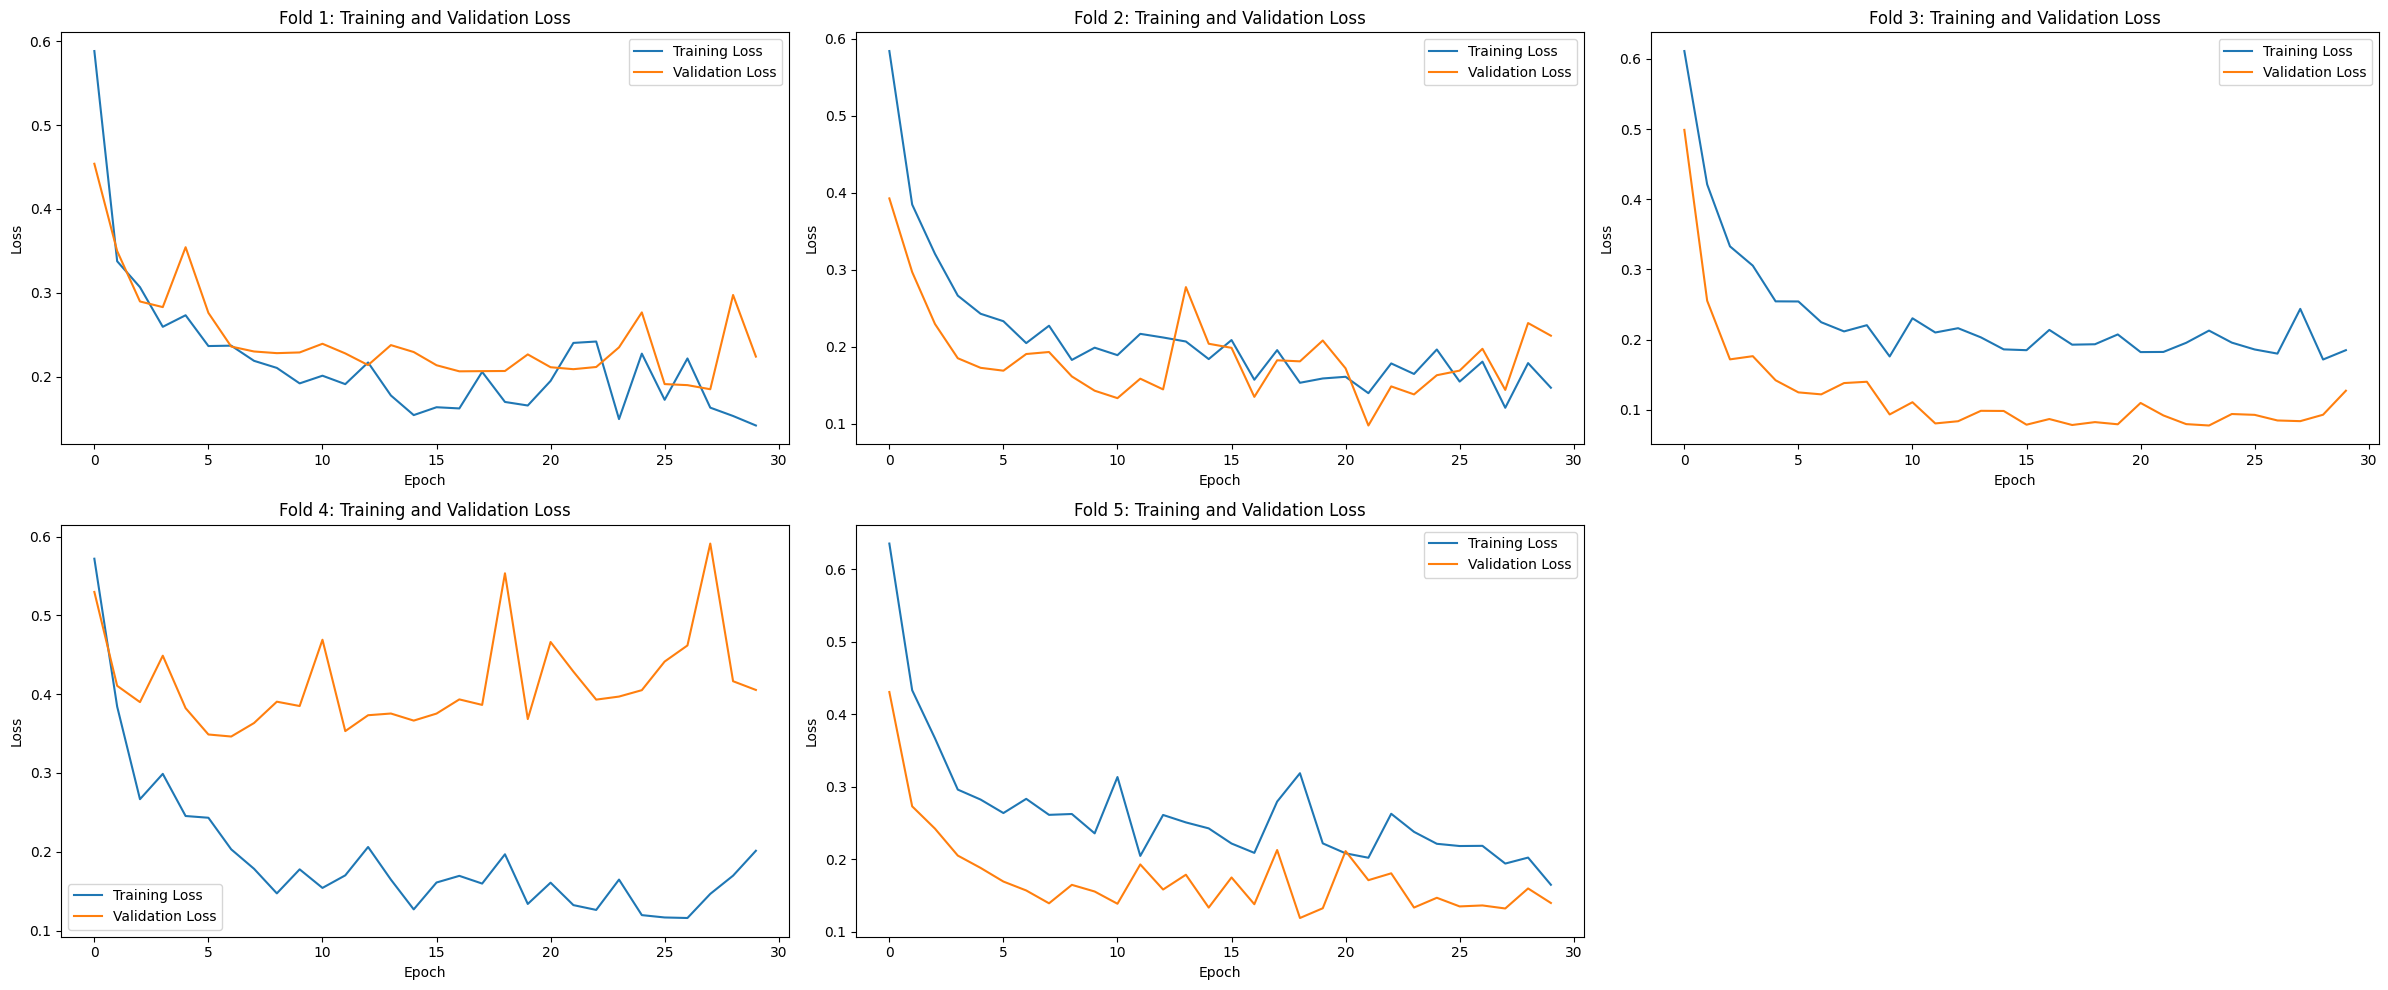

In [26]:
# Plot train and validation losses for each fold (patch-level)
# Note: validation set included all patches from the cores (some with unknown labels), so is less interpretable
def plot_losses(fold_num, train_losses, val_losses, ax):
    ax.plot(train_losses, label='Training Loss')
    ax.plot(val_losses, label='Validation Loss')
    ax.set_title(f'Fold {fold_num}: Training and Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

fig, axes = plt.subplots(2, 3, figsize=(24, 10)) 

for fold in range(num_folds):
    row = fold // 3 
    col = fold % 3  
    ax = axes[row, col]
    plot_losses(fold + 1, all_train_losses[fold], all_val_losses[fold], ax)

fig.delaxes(axes[1, 2])
plt.tight_layout()
plt.show()